# Audio-JEPA

Trying to implement JEPA for audio — the idea is to train a model that predicts
text-space embeddings from audio without ever doing direct transcription during pretraining.

Two-phase training:
1. Train the predictor + text encoder together using InfoNCE (contrastive loss)
2. Freeze everything and train a small decoder on top to actually output text

Using LibriSpeech + HuBERT as the frozen audio backbone.

In [2]:
import torch, sys
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# check torch version - 2.6+ required due to CVE-2025-32434
major, minor = [int(x) for x in torch.__version__.split("+")[0].split(".")[:2]]
if (major, minor) < (2, 6):
    print(f"ERROR: torch {torch.__version__} is too old. Need 2.6+")
    print("Run in terminal: pip install --upgrade torch --index-url https://download.pytorch.org/whl/cu121")
    print("Then restart the kernel and rerun this cell.")
else:
    print(f"torch version OK ({torch.__version__})")
    # install other deps
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "transformers", "datasets", "sentence-transformers",
                    "soundfile", "librosa", "jiwer"])
    print("deps installed")


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
torch version OK (2.11.0+cu128)
deps installed


## Model

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import HubertModel, AutoTokenizer, AutoModel


# audio encoder - just wraps hubert and keeps it frozen
# loads straight to GPU to avoid the annoying CPU->GPU copy on every forward pass
class XEncoder(nn.Module):
    def __init__(self, model_name='facebook/hubert-base-ls960'):
        super().__init__()
        dev = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.hubert = HubertModel.from_pretrained(model_name).to(dev)
        for p in self.hubert.parameters():
            p.requires_grad = False
        self.hidden_size = self.hubert.config.hidden_size  # 768

    def forward(self, audio, mask=None):
        dev = next(self.hubert.parameters()).device
        audio = audio.to(dev)
        if mask is not None:
            mask = mask.to(dev)
        with torch.no_grad():
            out = self.hubert(input_values=audio, attention_mask=mask)
        return out.last_hidden_state  # (B, T, 768)


# sliding window attention so we dont blow up memory on long audio sequences
# the nan_to_num fix is important - rows that are all padding become -inf after
# masking and softmax turns them into nan, which then poisons everything downstream
class SlidingWindowAttention(nn.Module):
    def __init__(self, d_model, n_heads, window=64):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dh = d_model // n_heads
        self.w = window
        self.scale = self.dh ** -0.5
        self.q = nn.Linear(d_model, d_model, bias=False)
        self.k = nn.Linear(d_model, d_model, bias=False)
        self.v = nn.Linear(d_model, d_model, bias=False)
        self.o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, pad_mask=None):
        B, T, D = x.shape
        H, Hd = self.h, self.dh

        Q = self.q(x).view(B, T, H, Hd).transpose(1, 2)
        K = self.k(x).view(B, T, H, Hd).transpose(1, 2)
        V = self.v(x).view(B, T, H, Hd).transpose(1, 2)

        pos = torch.arange(T, device=x.device)
        window_mask = (pos.unsqueeze(0) - pos.unsqueeze(1)).abs() > self.w
        window_mask = window_mask.unsqueeze(0).unsqueeze(0)

        attn = (Q @ K.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(window_mask, float('-inf'))
        if pad_mask is not None:
            attn = attn.masked_fill(pad_mask.unsqueeze(1).unsqueeze(2), float('-inf'))

        attn = torch.softmax(attn, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)  # handle all-padding rows

        out = (attn @ V).transpose(1, 2).reshape(B, T, D)
        return self.o(out)


class PredictorBlock(nn.Module):
    def __init__(self, d, heads, window=64, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attn = SlidingWindowAttention(d, heads, window)
        self.norm2 = nn.LayerNorm(d)
        self.gate = nn.Linear(d, d * 4, bias=False)
        self.up = nn.Linear(d, d * 4, bias=False)
        self.down = nn.Linear(d * 4, d, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        x = x + self.drop(self.attn(self.norm1(x), pad_mask))
        h = self.norm2(x)
        x = x + self.drop(self.down(F.silu(self.gate(h)) * self.up(h)))
        return x


# takes the hubert frames and produces a single embedding vector
# that should end up close to the text embedding of the transcript
class Predictor(nn.Module):
    def __init__(self, in_dim=768, d=512, heads=8, layers=6, out_dim=512, window=64, dropout=0.1):
        super().__init__()
        self.proj_in = nn.Linear(in_dim, d, bias=False)
        self.blocks = nn.ModuleList([
            PredictorBlock(d, heads, window, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(d)
        self.proj_out = nn.Linear(d, out_dim, bias=False)

    def forward(self, x, pad_mask=None):
        x = self.proj_in(x)
        for blk in self.blocks:
            x = blk(x, pad_mask)
        x = self.norm(x)
        if pad_mask is not None:
            valid = (~pad_mask).float().unsqueeze(-1)
            pooled = (x * valid).sum(1) / valid.sum(1).clamp(min=1e-9)
        else:
            pooled = x.mean(1)
        return F.normalize(self.proj_out(pooled), dim=-1)


# text encoder - sentence transformer, also frozen
# we just use it to get text embeddings to compare against audio predictions
class YEncoder(nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2', out_dim=512):
        super().__init__()
        dev = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.tok = AutoTokenizer.from_pretrained(model_name)
        self.enc = AutoModel.from_pretrained(model_name).to(dev)
        self.proj = nn.Linear(self.enc.config.hidden_size, out_dim, bias=False)

    def forward(self, texts):
        dev = next(self.enc.parameters()).device
        enc = self.tok(texts, padding=True, truncation=True,
                       max_length=128, return_tensors='pt').to(dev)
        out = self.enc(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return F.normalize(self.proj(pooled), dim=-1)


# small autoregressive decoder for phase 2
# takes the predicted embedding and decodes it into tokens
class YDecoder(nn.Module):
    def __init__(self, vocab=32000, d=256, heads=4, layers=4, ctx_dim=512, max_len=128, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(max_len + 1, d)
        self.ctx_proj = nn.Linear(ctx_dim, d, bias=False)
        dec = nn.TransformerDecoderLayer(d, heads, d * 4, dropout, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec, layers)
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.max_len = max_len

    def forward(self, ctx, tgt_ids):
        B, L = tgt_ids.shape
        dev = ctx.device
        tgt_ids = tgt_ids.to(dev)  # ensure target ids are on same device as context
        mem = self.ctx_proj(ctx).unsqueeze(1)
        pos = torch.arange(L, device=dev).unsqueeze(0)
        tgt = self.tok_emb(tgt_ids) + self.pos_emb(pos + 1)
        causal = nn.Transformer.generate_square_subsequent_mask(L, device=dev)
        out = self.decoder(tgt, mem, tgt_mask=causal)
        return self.head(self.norm(out))

    @torch.no_grad()
    def generate(self, ctx, bos_id, eos_id, tokenizer):
        B, dev = ctx.size(0), ctx.device
        mem = self.ctx_proj(ctx).unsqueeze(1)
        gen = torch.full((B, 1), bos_id, dtype=torch.long, device=dev)
        done = torch.zeros(B, dtype=torch.bool, device=dev)
        for _ in range(self.max_len):
            L = gen.size(1)
            pos = torch.arange(L, device=dev).unsqueeze(0)
            tgt = self.tok_emb(gen) + self.pos_emb(pos + 1)
            cm = nn.Transformer.generate_square_subsequent_mask(L, device=dev)
            out = self.decoder(tgt, mem, tgt_mask=cm)
            nxt = self.head(self.norm(out))[:, -1].argmax(-1)
            nxt = nxt.masked_fill(done, eos_id)
            gen = torch.cat([gen, nxt.unsqueeze(1)], dim=1)
            done = done | (nxt == eos_id)
            if done.all():
                break
        results = []
        for seq in gen.tolist():
            end = seq.index(eos_id) if eos_id in seq else len(seq)
            results.append(tokenizer.decode(seq[1:end], skip_special_tokens=True))
        return results


class AudioJEPA(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.x_encoder = XEncoder()
        self.predictor = Predictor(self.x_encoder.hidden_size, out_dim=embed_dim)
        self.y_encoder = YEncoder(out_dim=embed_dim)
        self.y_decoder = YDecoder(ctx_dim=embed_dim)

    @property
    def device(self):
        return next(self.predictor.parameters()).device

    def forward(self, audio, texts, audio_mask=None, frame_mask=None):
        dev = self.device
        audio = audio.to(dev)
        if audio_mask is not None:
            audio_mask = audio_mask.to(dev)
        sv = self.x_encoder(audio, audio_mask)
        sv = sv.to(dev)  # make sure hubert output lands on predictor device
        s_hat = self.predictor(sv, frame_mask)
        sy = self.y_encoder(texts)
        sy = sy.to(dev)  # make sure text encoder output is on same device
        return s_hat, sy


if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'torch version: {torch.__version__}')
else:
    print('no GPU - running on CPU')


c:\Users\sivag\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 3050 Laptop GPU
torch version: 2.11.0+cu128


## Loss

In [4]:
# InfoNCE loss — standard contrastive loss like CLIP
# temperature is frozen for the first N steps because if you let it move too early
# the logits explode before the predictor has learned anything useful -> NaN
class InfoNCELoss(nn.Module):
    def __init__(self, temp=0.07, freeze_steps=200):
        super().__init__()
        self.log_temp = nn.Parameter(torch.tensor(temp).log())
        self.freeze_steps = freeze_steps
        self._step = 0

    @property
    def temperature(self):
        return self.log_temp.exp().clamp(0.01, 0.5)

    def forward(self, pred, target):
        self._step += 1
        self.log_temp.requires_grad_(self._step > self.freeze_steps)

        B = pred.size(0)
        t = self.temperature
        logits = (pred @ target.T) / t
        labels = torch.arange(B, device=pred.device)

        loss = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

        with torch.no_grad():
            alignment = (pred * target).sum(-1).mean()
            dists = torch.cdist(pred, pred).pow(2)
            uniformity = dists.masked_fill(
                torch.eye(B, device=dists.device, dtype=torch.bool), 0
            ).sum() / (B * (B - 1))

        return {
            'loss': loss,
            'alignment': alignment,
            'uniformity': uniformity,
            'temperature': t.detach()
        }


print('InfoNCELoss defined')


InfoNCELoss defined


## Dataset

In [5]:
import os, math, time
import numpy as np
import soundfile as sf
import io
from torch.utils.data import Dataset, DataLoader

# must set audio backend BEFORE importing datasets
# otherwise it tries to load torchcodec which fails on Windows without FFmpeg
import os
os.environ['FORCE_SOUNDFILE_FOR_DATASETS'] = '1'

import datasets as hf_datasets
# tell datasets to use soundfile instead of torchcodec
try:
    hf_datasets.config.AUDIO_DECODE_BACKEND = 'soundfile'
except Exception:
    pass
try:
    import datasets.features.audio as _hf_audio
    _hf_audio.config.AUDIO_DECODE_BACKEND = 'soundfile'
except Exception:
    pass

from datasets import load_dataset

SMOKE_TEST = False
SMOKE_TRAIN_N = 2000
SMOKE_VAL_N = 200
SMOKE_AUDIO_LEN = 16000


class SyntheticAudioDataset(Dataset):
    PHRASES = ['hello world', 'test audio', 'smoke test', 'random noise', 'quick check']

    def __init__(self, n=200, length=SMOKE_AUDIO_LEN):
        self.n = n
        self.length = length
        print(f'synthetic: {n} samples, {length/16000:.1f}s each')

    def __len__(self): return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(seed=idx)
        t = np.linspace(0, self.length / 16000, self.length, dtype=np.float32)
        freqs = rng.uniform(80, 3400, size=rng.integers(4, 9))
        wave = sum(np.sin(2 * np.pi * f * t) for f in freqs).astype(np.float32)
        wave += rng.normal(0, 0.05, size=self.length).astype(np.float32)
        wave = torch.from_numpy(wave)
        wave = (wave - wave.mean()) / (wave.std() + 1e-9)
        wave = wave.clamp(-3.0, 3.0)
        return wave, self.PHRASES[idx % len(self.PHRASES)]


def decode_audio(item, max_len=320000):
    # decode audio manually with soundfile - avoids torchcodec entirely
    audio = item['audio']
    arr = audio.get('array', None)

    if arr is None or (hasattr(arr, '__len__') and len(arr) == 0):
        raw = audio.get('bytes', None)
        path = audio.get('path', None)
        if raw:
            arr, _ = sf.read(io.BytesIO(raw), dtype='float32')
        elif path and os.path.exists(path):
            arr, _ = sf.read(path, dtype='float32')
        else:
            arr = np.zeros(16000, dtype=np.float32)

    if not hasattr(arr, 'copy'):
        arr = np.array(arr, dtype=np.float32)
    if arr.ndim > 1:
        arr = arr.mean(axis=1)

    wave = torch.from_numpy(arr.copy()).float()
    wave = wave[:max_len]
    wave = (wave - wave.mean()) / (wave.std() + 1e-9)
    return wave


class LibriSpeechDataset(Dataset):
    def __init__(self, split='train.clean.100', max_sec=20.0, sr=16000, n=None):
        print(f'loading LibriSpeech {split}...')
        self.max_len = int(max_sec * sr)
        stream_split = (split
            .replace('train.clean.100', 'train.100')
            .replace('train.clean.360', 'train.360')
            .replace('validation.clean', 'validation')
            .replace('test.clean', 'test'))
        if n is not None:
            ds = load_dataset(
                'librispeech_asr', 'clean',
                split=stream_split,
                streaming=True,
            )
            # cast audio column to use soundfile decoder explicitly
            from datasets import Audio
            ds = ds.cast_column('audio', Audio(sampling_rate=16000, decode=True))
            self.data = []
            for sample in ds.take(n):
                # extract just what we need - text + raw bytes/path
                # avoid storing decoded arrays which eat RAM
                self.data.append({
                    'audio': {
                        'array': sample['audio'].get('array', None),
                        'bytes': sample['audio'].get('bytes', None),
                        'path':  sample['audio'].get('path', None),
                    },
                    'text': sample['text']
                })
            print(f'  got {len(self.data)} samples')
        else:
            self.data = load_dataset('librispeech_asr', 'clean', split=split)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        wave = decode_audio(item, self.max_len)
        return wave, item['text'].lower().strip()


def collate_fn(batch):
    waves, texts = zip(*batch)
    lengths = [w.size(0) for w in waves]
    T = max(lengths)
    audio = torch.zeros(len(waves), T)
    mask = torch.zeros(len(waves), T, dtype=torch.long)
    for i, (w, l) in enumerate(zip(waves, lengths)):
        audio[i, :l] = w
        mask[i, :l] = 1
    return audio, mask, list(texts)


print('dataset ready')


dataset ready


## Sanity check
quick forward pass to make sure nothing is broken before starting training

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
if device == 'cuda':
    torch.cuda.empty_cache()
    print(f'GPU: {torch.cuda.get_device_name(0)}')

model = AudioJEPA(embed_dim=512).to(device)
criterion = InfoNCELoss(freeze_steps=200).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'params: {trainable/1e6:.1f}M trainable / {total/1e6:.1f}M total')

# verify every submodule is actually on GPU
if device == 'cuda':
    for name, mod in model.named_children():
        try:
            dev = next(mod.parameters()).device
            print(f'  {name}: {dev}')
        except StopIteration:
            pass
    print(f'GPU mem after load: {torch.cuda.memory_allocated()/1e9:.2f} / '
          f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# forward pass check
print('\nchecking forward pass...')
all_ok = True
for i in range(3):
    audio = torch.randn(4, 16000 * 3).to(device)
    texts = ['hello world', 'the quick brown fox', 'good morning', 'test audio']
    with torch.no_grad():
        s_hat, sy = model(audio, texts)
    if torch.isnan(s_hat).any() or torch.isnan(sy).any():
        print(f'  run {i+1}: NaN detected!')
        all_ok = False
    else:
        res = criterion(s_hat, sy)
        gpu_mem = f'  GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB' if device == 'cuda' else ''
        print(f'  run {i+1}: loss={res["loss"].item():.4f}  align={res["alignment"].item():.4f}{gpu_mem}')

print('all good' if all_ok else 'NaN detected!')


device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5035.12it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


params: 69.5M trainable / 163.9M total
  x_encoder: cuda:0
  predictor: cuda:0
  y_encoder: cuda:0
  y_decoder: cuda:0
GPU mem after load: 0.66 / 4.3 GB

checking forward pass...
  run 1: loss=1.3659  align=-0.0451  GPU mem: 0.67 GB
  run 2: loss=1.4526  align=-0.0527  GPU mem: 0.67 GB
  run 3: loss=1.4145  align=-0.0508  GPU mem: 0.67 GB
all good


## Training

Two phases:
- **Phase 1**: train predictor + text encoder with InfoNCE — learns to align audio and text embeddings
- **Phase 2**: freeze everything, train decoder with cross-entropy — learns to generate text from the learned embeddings

In [7]:
BATCH_SIZE = 8
GRAD_ACCUM = 4       # effective batch = 32
LR = 1e-4
LOG_EVERY = 25
SAVE_EVERY = 250
EMBED_DIM = 512
CKPT_DIR = '/content/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# phase 1: ~4 epochs over 2000 samples with batch 8
# phase 2: ~2 epochs, decoder converges pretty fast
PHASE1_STEPS = 1000
PHASE1_WARMUP = 100
PHASE2_STEPS = 500
PHASE2_WARMUP = 50

USE_AMP = True  # fp16 is stable with real audio and gives ~2x speedup on T4
print(f'AMP: {USE_AMP}')


def cosine_lr(step, warmup, total):
    if step < warmup:
        return step / max(warmup, 1)
    t = (step - warmup) / max(total - warmup, 1)
    return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * t))


def train_phase(name, model, loader, optimizer, scaler, steps, warmup, loss_fn, device):
    history = {'step': [], 'loss': [], 'alignment': [], 'uniformity': [], 'temperature': []}
    step = accum = nan_count = consec_nan = 0
    optimizer.zero_grad()
    model.train()
    t0 = time.time()

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'  {steps} steps  |  warmup {warmup}  |  lr {LR}  |  batch {BATCH_SIZE}x{GRAD_ACCUM}')
    print(f'{"="*55}')

    for epoch in range(9999):
        for batch in loader:
            if step >= steps:
                break
            try:
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    res, extra = loss_fn(batch, model, device)
                if torch.isnan(res['loss']):
                    raise ValueError('nan')
            except ValueError:
                nan_count += 1
                consec_nan += 1
                if consec_nan <= 5:
                    print(f'  [warn] NaN at step {step} ({nan_count} total)')
                if consec_nan >= 20:
                    raise RuntimeError(f'too many NaN batches in {name}, something is wrong')
                optimizer.zero_grad()
                accum = 0
                continue

            consec_nan = 0
            scaler.scale(res['loss'] / GRAD_ACCUM).backward()
            accum += 1
            if accum < GRAD_ACCUM:
                continue

            for pg in optimizer.param_groups:
                pg['lr'] = LR * cosine_lr(step, warmup, steps)

            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            accum = 0
            step += 1

            if step % LOG_EVERY == 0:
                gpu_str = f' | gpu {torch.cuda.memory_allocated()/1e9:.1f}GB' if device == 'cuda' else ''
                print(f'  step {step:4d} | loss {res["loss"].item():.4f} | {extra} | {time.time()-t0:.1f}s{gpu_str}')
                history['step'].append(step)
                history['loss'].append(res['loss'].item())
                for k in ['alignment', 'uniformity', 'temperature']:
                    if k in res:
                        history[k].append(res[k].item())
                t0 = time.time()

            if step % SAVE_EVERY == 0:
                ckpt = f'{CKPT_DIR}/{name.replace(" ", "_")}_step{step:05d}.pt'
                torch.save({'step': step, 'model': model.state_dict()}, ckpt)
                print(f'  saved {ckpt}')

        if step >= steps:
            break

    if history['loss']:
        print(f'\n  done: {history["loss"][0]:.4f} -> {history["loss"][-1]:.4f}  ({nan_count} NaN skips)')
    return history


# build model and data
model = AudioJEPA(embed_dim=EMBED_DIM).to(device)
criterion = InfoNCELoss(freeze_steps=100).to(device)

# verify GPU is actually being used before spending time on training
if device == 'cuda':
    for name, mod in model.named_children():
        try:
            d = next(mod.parameters()).device
            print(f'  {name}: {d}')
        except StopIteration:
            pass
    print(f'GPU mem after model init: {torch.cuda.memory_allocated()/1e9:.2f} GB')
    if torch.cuda.memory_allocated() < 1e8:  # less than 100MB means something is wrong
        print('WARNING: very little GPU memory used — models may not be on GPU!')

if SMOKE_TEST:
    print('smoke test mode - using synthetic data')
    train_ds = SyntheticAudioDataset(n=SMOKE_TRAIN_N)
    val_ds = SyntheticAudioDataset(n=SMOKE_VAL_N)
else:
    print('real data mode - streaming from LibriSpeech')
    train_ds = LibriSpeechDataset(split='train.clean.100', n=SMOKE_TRAIN_N)
    val_ds = LibriSpeechDataset(split='validation.clean', n=SMOKE_VAL_N)

# num_workers=0 on Colab — multiprocessing workers don't share CUDA context
# pin_memory=True speeds up the CPU->GPU copy for each batch
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=(device=='cuda'),
                      collate_fn=collate_fn, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=0, pin_memory=(device=='cuda'),
                    collate_fn=collate_fn)


# phase 1 - train predictor + text encoder, decoder stays frozen
for p in model.y_decoder.parameters():
    p.requires_grad = False

p1_params = (
    list(model.predictor.parameters())
    + [p for p in model.y_encoder.parameters() if p.requires_grad]
    + list(criterion.parameters())
)
opt1 = torch.optim.Adam(p1_params, lr=LR)
scaler1 = torch.amp.GradScaler('cuda', enabled=USE_AMP)


def phase1_loss(batch, model, device):
    audio, mask, texts = batch
    audio, mask = audio.to(device), mask.to(device)
    s_hat, sy = model(audio, texts, mask)
    if torch.isnan(s_hat).any() or torch.isnan(sy).any():
        raise ValueError('nan')
    res = criterion(s_hat, sy)
    return res, f'align {res["alignment"].item():.4f} | temp {res["temperature"].item():.4f}'


h1 = train_phase('Phase 1 — predictor + text encoder (InfoNCE)',
                 model, train_dl, opt1, scaler1,
                 PHASE1_STEPS, PHASE1_WARMUP, phase1_loss, device)

torch.save({'model': model.state_dict(), 'criterion': criterion.state_dict()},
           f'{CKPT_DIR}/phase1_final.pt')
print('phase 1 checkpoint saved')


# phase 2 - freeze everything, train decoder only
for p in model.x_encoder.parameters(): p.requires_grad = False
for p in model.predictor.parameters(): p.requires_grad = False
for p in model.y_encoder.parameters(): p.requires_grad = False
for p in model.y_decoder.parameters(): p.requires_grad = True

from transformers import AutoTokenizer as HFTok
_tok = HFTok.from_pretrained('facebook/opt-125m')
_tok.add_special_tokens({'pad_token': '[PAD]'})
VOCAB_SIZE = len(_tok)

# resize vocab if it doesn't match
if model.y_decoder.head.out_features != VOCAB_SIZE:
    d = model.y_decoder.tok_emb.embedding_dim
    model.y_decoder.tok_emb = nn.Embedding(VOCAB_SIZE, d).to(device)
    model.y_decoder.head = nn.Linear(model.y_decoder.norm.normalized_shape[0], VOCAB_SIZE, bias=False).to(device)

opt2 = torch.optim.Adam(model.y_decoder.parameters(), lr=LR)
scaler2 = torch.amp.GradScaler('cuda', enabled=USE_AMP)
ce = nn.CrossEntropyLoss(ignore_index=_tok.pad_token_id)


def phase2_loss(batch, model, device):
    audio, mask, texts = batch
    audio, mask = audio.to(device), mask.to(device)
    enc = _tok(list(texts), return_tensors='pt', padding=True, truncation=True, max_length=64)
    tgt = enc['input_ids'].to(device)
    with torch.no_grad():
        sv = model.x_encoder(audio, mask)
        s_hat = model.predictor(sv)
    logits = model.y_decoder(s_hat, tgt[:, :-1])
    if torch.isnan(logits).any():
        raise ValueError('nan')
    loss = ce(logits.reshape(-1, VOCAB_SIZE), tgt[:, 1:].reshape(-1))
    return {'loss': loss}, f'ppl {loss.exp().item():.1f}'


h2 = train_phase('Phase 2 — decoder (cross-entropy)',
                 model, train_dl, opt2, scaler2,
                 PHASE2_STEPS, PHASE2_WARMUP, phase2_loss, device)

torch.save({'model': model.state_dict()}, f'{CKPT_DIR}/phase2_final.pt')
print('phase 2 checkpoint saved')
print(f'\ndone!')
print(f'  phase 1: {h1["loss"][0]:.4f} -> {h1["loss"][-1]:.4f}')
print(f'  phase 2: {h2["loss"][0]:.4f} -> {h2["loss"][-1]:.4f}')


AMP: True


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3597.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  x_encoder: cuda:0
  predictor: cuda:0
  y_encoder: cuda:0
  y_decoder: cuda:0
GPU mem after model init: 0.69 GB
real data mode - streaming from LibriSpeech
loading LibriSpeech train.clean.100...


  got 2000 samples
loading LibriSpeech validation.clean...
  got 200 samples

  Phase 1 — predictor + text encoder (InfoNCE)
  1000 steps  |  warmup 100  |  lr 0.0001  |  batch 8x4
  step   25 | loss 1.6498 | align 0.0222 | temp 0.0700 | 460.5s | gpu 1.1GB
  step   50 | loss 0.9267 | align 0.1801 | temp 0.0699 | 492.8s | gpu 1.1GB
  step   75 | loss 0.5203 | align 0.3569 | temp 0.0698 | 571.4s | gpu 1.1GB
  step  100 | loss 0.3237 | align 0.3565 | temp 0.0697 | 580.6s | gpu 1.1GB
  step  125 | loss 0.1879 | align 0.4284 | temp 0.0696 | 580.3s | gpu 1.1GB
  step  150 | loss 0.4853 | align 0.4247 | temp 0.0694 | 575.6s | gpu 1.1GB
  step  175 | loss 0.0990 | align 0.4963 | temp 0.0693 | 604.6s | gpu 1.1GB
  step  200 | loss 0.1053 | align 0.5295 | temp 0.0692 | 572.0s | gpu 1.1GB
  step  225 | loss 0.1538 | align 0.5127 | temp 0.0691 | 611.5s | gpu 1.1GB
  step  250 | loss 0.0192 | align 0.6166 | temp 0.0690 | 619.2s | gpu 1.1GB
  saved /content/checkpoints/Phase_1_—_predictor_+_text_enc

c:\Users\sivag\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sivag\.cache\huggingface\hub\models--facebook--opt-125m. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



  Phase 2 — decoder (cross-entropy)
  500 steps  |  warmup 50  |  lr 0.0001  |  batch 8x4
  step   25 | loss 10.7421 | ppl 46264.5 | 228.8s | gpu 1.4GB
  step   50 | loss 9.8814 | ppl 19562.6 | 220.4s | gpu 1.4GB
  step   75 | loss 8.9645 | ppl 7820.1 | 221.6s | gpu 1.4GB
  step  100 | loss 8.2251 | ppl 3733.7 | 223.5s | gpu 1.4GB
  step  125 | loss 7.9256 | ppl 2767.4 | 213.5s | gpu 1.4GB
  step  150 | loss 7.6042 | ppl 2006.6 | 225.5s | gpu 1.4GB
  step  175 | loss 7.3944 | ppl 1626.9 | 213.5s | gpu 1.4GB
  step  200 | loss 7.1076 | ppl 1221.2 | 220.5s | gpu 1.4GB
  step  225 | loss 7.1127 | ppl 1227.5 | 212.8s | gpu 1.4GB
  step  250 | loss 7.0375 | ppl 1138.6 | 228.6s | gpu 1.4GB
  saved /content/checkpoints/Phase_2_—_decoder_(cross-entropy)_step00250.pt
  step  275 | loss 6.9337 | ppl 1026.3 | 225.2s | gpu 1.4GB
  step  300 | loss 6.9829 | ppl 1078.1 | 226.6s | gpu 1.4GB
  step  325 | loss 7.1035 | ppl 1216.2 | 217.7s | gpu 1.4GB
  step  350 | loss 7.0086 | ppl 1106.2 | 214.2s | 

## Results

In [10]:
pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 162.5 kB/s eta 0:00:01
     ---------------------- --------------- 30.7/52.8 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 302.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------------------------ -------- 92.2/119.8 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.1 MB 2.3 MB/s eta 0:00:04
    --------------------------------------- 0.2/8.1 MB 1.7 MB/s eta 0:00:05
   - -------------------------------------- 0.3/8.1 MB 1.7 MB/s eta 0:00:05
   - -------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


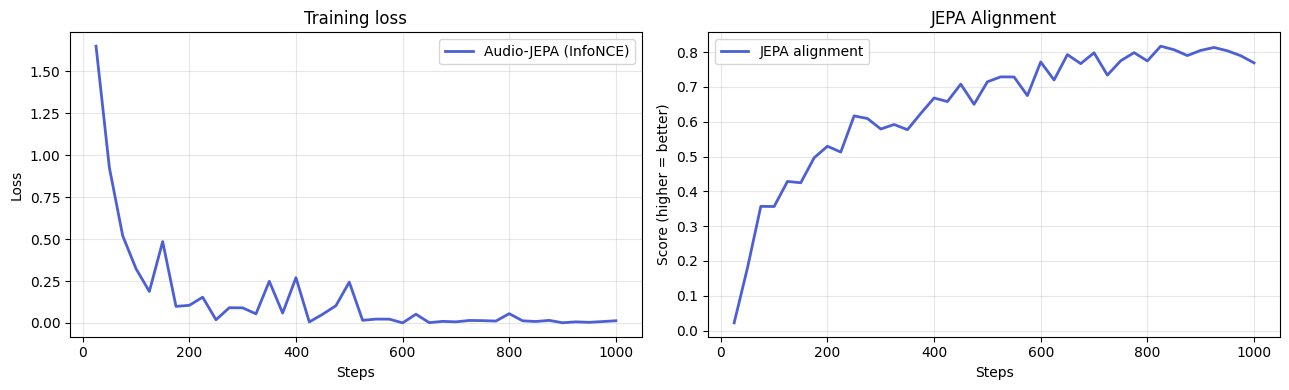

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Plot training loss
ax1.plot(h1['step'], h1['loss'], color='#4C5FD5', lw=2, label='Audio-JEPA (InfoNCE)')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.set_title('Training loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot JEPA alignment only
ax2.plot(h1['step'], h1['alignment'], color='#4C5FD5', lw=2, label='JEPA alignment')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Score (higher = better)')
ax2.set_title('JEPA Alignment')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results.png', dpi=150, bbox_inches='tight')
plt.show()

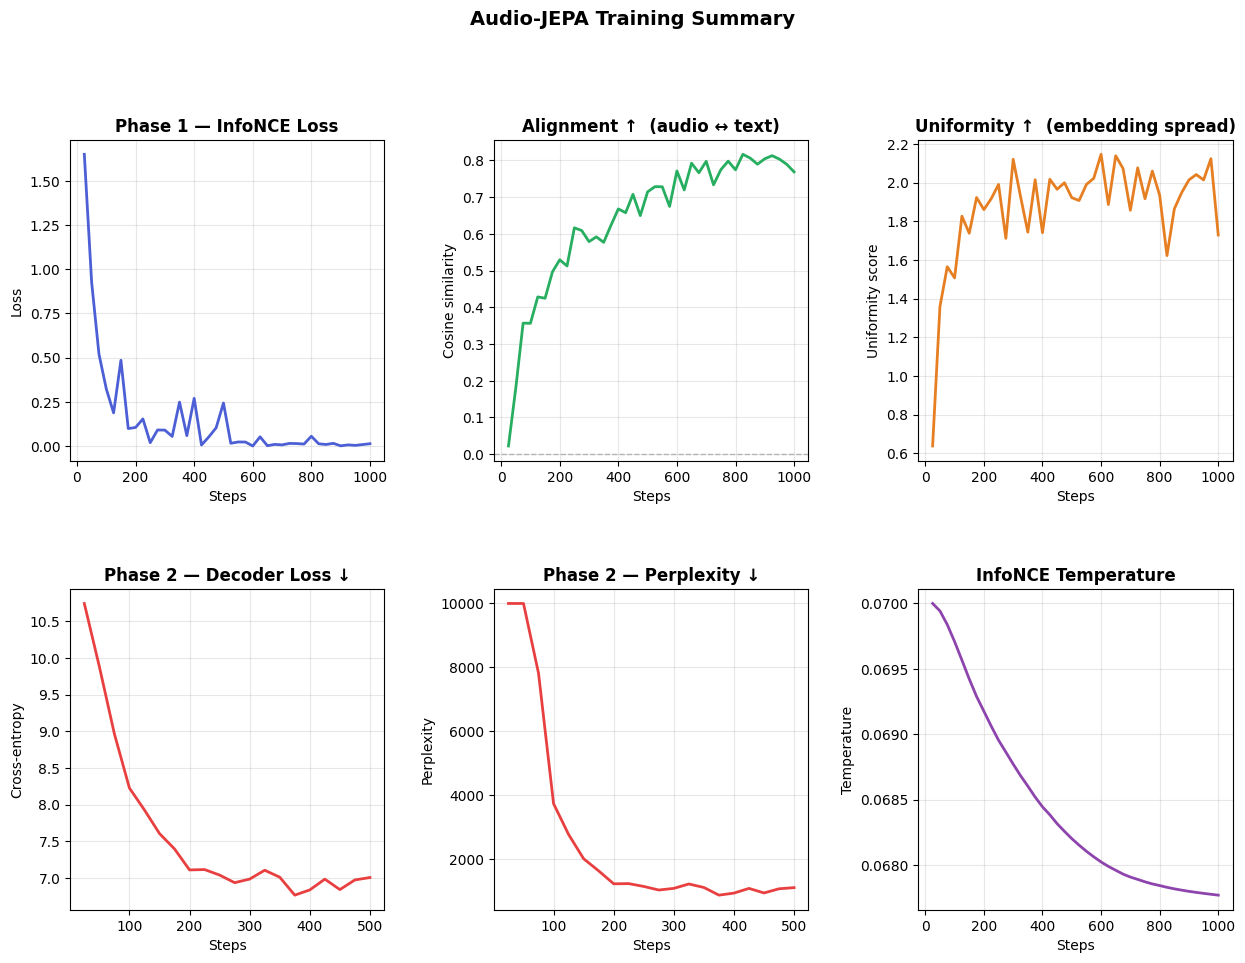


── Training Summary ──────────────────────────
Phase 1  steps : 1000
         loss  : 1.6498 → 0.0135
         align : 0.0222 → 0.7690
Phase 2  steps : 500
         loss  : 10.7421 → 7.0039
         ppl   : 46213.0 → 1100.1


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Phase 1 plots ─────────────────────────────────────────────────────────────

# 1. InfoNCE loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(h1['step'], h1['loss'], color='#4C5FD5', lw=2)
ax1.set_title('Phase 1 — InfoNCE Loss', fontweight='bold')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

# 2. Alignment score (how close audio prediction is to text embedding)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(h1['step'], h1['alignment'], color='#27AE60', lw=2)
ax2.axhline(0, color='gray', lw=1, ls='--', alpha=0.5)
ax2.set_title('Alignment ↑  (audio ↔ text)', fontweight='bold')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Cosine similarity')
ax2.grid(alpha=0.3)

# 3. Uniformity (how spread out embeddings are — higher = more diverse)
ax3 = fig.add_subplot(gs[0, 2])
if h1.get('uniformity'):
    ax3.plot(h1['step'], h1['uniformity'], color='#E67E22', lw=2)
    ax3.set_title('Uniformity ↑  (embedding spread)', fontweight='bold')
    ax3.set_xlabel('Steps')
    ax3.set_ylabel('Uniformity score')
    ax3.grid(alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'no uniformity data', ha='center', va='center',
             transform=ax3.transAxes, color='gray')
    ax3.set_title('Uniformity', fontweight='bold')

# ── Phase 2 plots ─────────────────────────────────────────────────────────────

# 4. Decoder cross-entropy loss
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(h2['step'], h2['loss'], color='#E84040', lw=2)
ax4.set_title('Phase 2 — Decoder Loss ↓', fontweight='bold')
ax4.set_xlabel('Steps')
ax4.set_ylabel('Cross-entropy')
ax4.grid(alpha=0.3)

# 5. Perplexity (exp of CE loss) — easier to interpret
ax5 = fig.add_subplot(gs[1, 1])
ppl = [min(2.718**l, 10000) for l in h2['loss']]  # cap at 10k for readability
ax5.plot(h2['step'], ppl, color='#E84040', lw=2)
ax5.set_title('Phase 2 — Perplexity ↓', fontweight='bold')
ax5.set_xlabel('Steps')
ax5.set_ylabel('Perplexity')
ax5.grid(alpha=0.3)

# 6. Phase 1 temperature (should stay stable after freeze_steps)
ax6 = fig.add_subplot(gs[1, 2])
if h1.get('temperature'):
    ax6.plot(h1['step'], h1['temperature'], color='#8E44AD', lw=2)
    ax6.set_title('InfoNCE Temperature', fontweight='bold')
    ax6.set_xlabel('Steps')
    ax6.set_ylabel('Temperature')
    ax6.grid(alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'no temperature data', ha='center', va='center',
             transform=ax6.transAxes, color='gray')
    ax6.set_title('Temperature', fontweight='bold')

fig.suptitle('Audio-JEPA Training Summary', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('jepa_results.png', dpi=150, bbox_inches='tight')
plt.show()

# print a quick summary too
print('\n── Training Summary ──────────────────────────')
print(f'Phase 1  steps : {h1["step"][-1]}')
print(f'         loss  : {h1["loss"][0]:.4f} → {h1["loss"][-1]:.4f}')
print(f'         align : {h1["alignment"][0]:.4f} → {h1["alignment"][-1]:.4f}')
print(f'Phase 2  steps : {h2["step"][-1]}')
print(f'         loss  : {h2["loss"][0]:.4f} → {h2["loss"][-1]:.4f}')
print(f'         ppl   : {2.718**h2["loss"][0]:.1f} → {2.718**h2["loss"][-1]:.1f}')
